---
title: Performance of the feedback control system
jupyter:
  jupytext:
    cell_metadata_filter: '-all'
    formats: ipynb,md,qmd,pdf
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.18.1
  kernelspec:
    display_name: Python 3 (ipykernel)
    language: python
    name: python3
---

In [1]:
import numpy as np
import sympy as sp
import control as ct
from ipywidgets import widgets, interact
from IPython.display import display
from matplotlib import pyplot as plt

# Introduction
The main advantage of feedback control systems is their ability to adjust both transient and steady-state performance. Analyzing and designing these systems involves defining performance and adjusting controller parameters for desired outcomes. Control systems exhibit transient responses that fade over time and steady-state responses that persist. Design specifications include time-response indices and steady-state accuracy, which can be revised for flexibility. These adjustments can be illustrated graphically.

![](pics/diag51.svg)

The specifications, which are stated in terms of the measures of performance, indicate the quality of the system to the designer. In other words, the performance measures help to answer the question, How well does the system perform the task for which it was designed?


# 2. Test input signal
Time-domain performance specifications are crucial for control systems, especially the transient response, which is vital for designers. Firstly, it's important to assess system stability. If stable, the system's response to standard test input signals can indicate performance levels, enabling effective comparisons between different designs. Many control systems also face input signals similar to these standard tests. The standard test input signals commonly used are the step input, the ramp input, and the parabolic input. These inputs are shown in the following table:

| Test signal |                        $r(t)$                        |     $R(s)$     |
| :---------- | :--------------------------------------------------: | :------------: |
| Step        |  $r(t)=\begin{cases}A,\;t>0\\0,\;t\leq0\end{cases}$  |  ${A\over s}$  |
| Ramp        | $r(t)=\begin{cases}At,\;t>0\\0,\;t\leq0\end{cases}$  | ${A\over s²}$  |
| Parabolic   | $r(t)=\begin{cases}At²,\;t>0\\0,\;t\leq0\end{cases}$ | ${2A\over s³}$ |

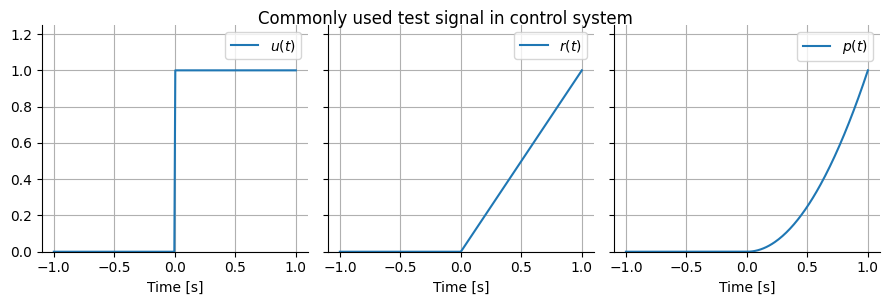

In [2]:
# run-python
A=1.0
tt = np.linspace(-1,1,256)
ut = np.where(tt>0,A,0)
rt = np.where(tt>0,A*tt,0)
pt =np.where(tt>0, A*tt**2,0.0)
tests = [ut,rt,pt]
labs = [r'$u(t)$',r'$r(t)$',r'$p(t)$']
fig, axs = plt.subplots(1,3,sharey=True,figsize=(9.0,3))
for ax, sig, lab in zip(axs,tests, labs):
	ax.plot(tt,sig,label=lab)
	ax.legend()
	ax.grid(True)
	ax.set_xlabel('Time [s]')
	ax.spines["top"].set_color("None")
	ax.spines["right"].set_color("None")
	ax.set_ylim([0.0,1.25*A])
fig.tight_layout()
fig.suptitle('Commonly used test signal in control system',y=1.0);

# 3. Performance of second order systems
Let us consider a single-loop second-order system and determine its response to a
unit step input. A closed-loop feedback control system is shown in following figure:

![](pics/diag52.svg)

The closed-loop transfer function is:
$$
H_{cl}(s)={P(s)\over 1+ P(s)} = {\omega_{n}²\over s²+2\zeta\omega_{n}s + \omega_{n}^2}
$$ 
Where $\omega_n$ is the natural frequency and $\zeta$ the damping ratio.

+ **Impulse response of the 2nd-order system:**

In [3]:
# run-python
wn = 1.0
num = [wn**2]
s = ct.TransferFunction.s
tt = np.linspace(0.0,15.0,512)
sys1 = wn**2 * s**0
sys2 = 1 / s

In [4]:
@interact(ζ=(0.1, 2.0, 0.2))
def plot_impulse_response(ζ=0.7):
    sys3 = 1 / (s + 2 * wn * ζ) 
    sys = ct.series(sys1,sys2,sys3).feedback(1)
    sys.impulse_response(tt).plot(label=rf'$\zeta={ζ}$', title='Impulse response of the 2nd-order system')
    plt.legend()
    plt.ylim(-1.0,1.0)
    plt.grid(True)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.ylabel(r'$y(t)$');

interactive(children=(FloatSlider(value=0.7, description='ζ', max=2.0, min=0.1, step=0.2), Output()), _dom_cla…

+ **Step response of the 2nd-order system:**

In [5]:
# run-python
@interact(ζ=(0.1, 2.0, 0.2))
def plot_step_response(ζ=0.7):
    sys3 = 1 / (s + 2 * wn * ζ) 
    sys = ct.series(sys1,sys2,sys3).feedback(1)
    sys.step_response(tt).plot(label=rf'$\zeta={ζ}$', title='Unit step response of the 2nd-order system')
    plt.axhline(y=0.98,color='k', ls='--',label=r'$1-\delta$')
    plt.axhline(y=1.02,color='k', ls='--',label=r'$1+\delta$')
    plt.legend(loc='center right')
    plt.ylim(0.0,1.2)
    plt.grid(True)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.ylabel(r'$y(t)$');

# plot_step_response()

interactive(children=(FloatSlider(value=0.7, description='ζ', max=2.0, min=0.1, step=0.2), Output()), _dom_cla…

The output of the 2nd-order system is given by calculating the inverse transform of the transfer function multiplied by the reference signal $R(s)={1\over s}$:

In [6]:
s, t, ωₙ, ζ = sp.symbols('s t ωₙ ζ')
H = ωₙ**2 / s / (s**2 + 2 * ωₙ * ζ * s + ωₙ**2)
print("\n\n")
with sp.assuming(ζ < 1, ζ > 0 , ωₙ > 0):
    y = sp.simplify(sp.inverse_laplace_transform(H,s,t))
y 

-ζ*ωₙ*exp(-t*ζ*ωₙ)*sin(t*sqrt(-ζ**2*ωₙ**2 + ωₙ**2))*Heaviside(t)/sqrt(-ζ**2*ωₙ**2 + ωₙ**2) + Heaviside(t) - exp(-t*ζ*ωₙ)*cos(t*ωₙ*sqrt(1 - ζ**2))*Heaviside(t)

In [7]:
@interact(zeta=(0.1,2.0,0.2))
def plot_symbolic_step_response(zeta=0.7):
    p = sp.plot(y.subs(ωₙ,1.0).subs(ζ,zeta),(t,0.0,14.0),show=False)
    data = p[0].get_data()
    tt , yout = data
    yout = yout.squeeze()
    fig = plt.figure()
    ax = fig.add_subplot()
    ax.plot(tt,yout,label=f'Step response for ζ = {round(zeta,ndigits=1)}')
    ax.set_xlabel('time [s]')
    ax.set_ylabel(r'$y_{out}(t)$')
    ax.legend(loc='center right')
    ax.grid()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

interactive(children=(FloatSlider(value=0.7, description='zeta', max=2.0, min=0.1, step=0.2), Output()), _dom_…

$$
y(t) = \left(1 - \sqrt{{1\over 1- \zeta²}}\exp(-\zeta\omega_{n}t)\sin\left(\sqrt{1-\zeta²}\omega_{n}t+\varphi\right)\right)u(t)\text{ where }\varphi =\cos^{-1}({\zeta}) 
$$
+ **Standard performance measures:**

  Standard performance measures are often defined in terms of the step response of the closed-loop system as shown in the following illustration:
![](pics/diag53.svg)

  The swiftness of the response is measured by:

| Performance            | Symbol   | Description                                                                                                                                                                                           |
| :--------------------- | :------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Rise time**          | $t_r$    | Time taken for the output to reach $90\%$ of the target reference value                                                                                                                               |
| **Peack time**         | $t_p$    | Time taken for the output to reach it's maximum value ($t_{p}={\pi\over\omega_{n}\sqrt{1-\zeta²}}$)                                                                                                   |
| **Percent overshoot**  | $PO$     | $${y(t_{p}) - \vert r(t)\vert\over \vert r(t)\vert }\times 100\% = 100\exp(-{\zeta\pi\over\sqrt{1-\zeta²}})(\%)$$ where $\vert r(t)\vert$ is the maximum magnitude of the test signal                 |
| **Settling time**      | $t_s$    | Time taken by the output to maintain it's value inside $[\vert r(t)\vert -\delta,\vert r(t)\vert +\delta]$ (example $\delta=2\%$ of the final value $\Rightarrow t_{s}\cong{4\over \omega_{n}\zeta}$) |
| **Steady-state error** | $e_{ss}$ | $$e_{ss} = \vert y(\infty) - \vert r(t)\vert\vert$$|

In general, the transient response of a 2nd-order system can be described in terms of two factors:
1. The *Swiftness of response* represented by the rise and peak times.
   + ***Rise time:***

| ![](pics/cap33.png) | ![](pics/cap32.png) |
| :------------: | -------------- |

We can approximate the normalized rise-time $t_{r1}$ by a quadratic formula as follow:

$$
t_{r1}\omega_{n}(\zeta)=2.23\zeta²-0.0785\zeta+1.1178
$$

+ ***Pick time***

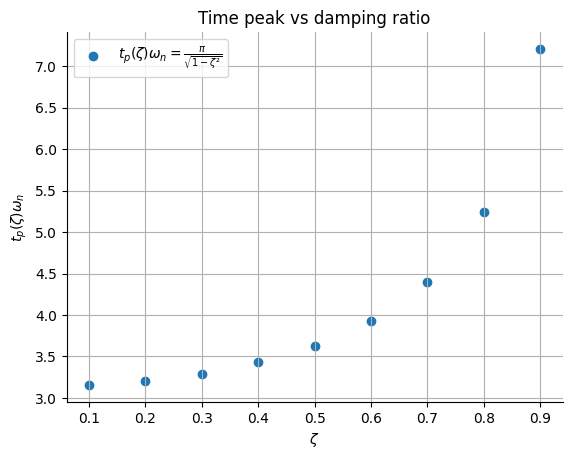

In [8]:
# run-python
def tp(ζ):
	return np.pi/np.sqrt(1-ζ**2)

ζs = np.arange(0.1,1.0,0.1)
tps = tp(ζs)

fig = plt.figure()
ax = fig.add_subplot(111)
ax.spines["top"].set_color("None")
ax.spines["right"].set_color("None")
ax.scatter(ζs,tps,label=r'$t_p(\zeta)\omega_n=\frac{\pi}{\sqrt{1-\zeta²}}$')
ax.set_title('Time peak vs damping ratio')
ax.set_xlabel(r'$\zeta$')
ax.set_ylabel(r'$t_p(\zeta)\omega_n$')
ax.grid(True)
ax.legend()
plt.show()

2. The *Closeness of response* to the desired response also represented by the percent overshoot and settling time.  

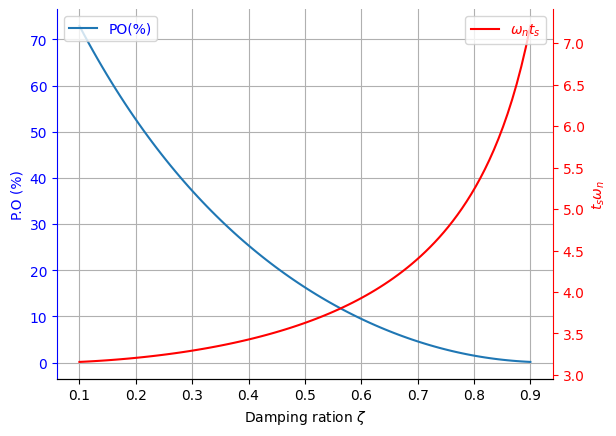

In [9]:
# run-python
zeta = np.linspace(0.1,0.9,100)
po = 100*np.exp(-np.pi*zeta/np.sqrt(1-zeta**2))
tp = np.pi/np.sqrt(1-zeta**2)
fig = plt.figure()
ax1 = fig.add_subplot(111)
ax1.plot(zeta,po,label='PO(%)')
ax1.grid(True)
ax1.legend(loc='upper left',labelcolor='blue')
ax1.set_xlabel(r'Damping ration $\zeta$')     
ax1.set_ylabel('P.O (%)',color='blue')
ax1.tick_params(axis='y', colors='blue')
ax2 = ax1.twinx()
ax2.plot(zeta,tp,label=r'$\omega_{n}t_{s}$',color='red')
ax2.legend(loc='upper right',labelcolor='red')
ax2.set_ylabel(r'$t_s\omega_n$',color='red')
ax2.tick_params(axis='y', colors='red')
for pos in ['top', 'right']:
    ax1.spines[pos].set_visible(False)
    if pos == 'right': pos='left'
    ax2.spines[pos].set_visible(False)
    
ax1.spines['left'].set_color('blue')
ax2.spines['right'].set_color('red')

# 4. Effects of third pole and zero on second order system response
Consider a 3nd-order system described by the given closed-loop normalized ($s = \frac{s'}{\omega_{n}}$) transfer function:
$$
H_{cl}(s)={1\over (s²+2\zeta s+1)(\gamma s+1)}
$$
The poles of this system are given below:

In [10]:
# run-python
from sympy import simplify, symbols, pprint, roots
from sympy.abc import s

zeta, gamma = symbols('zeta gamma')
Q = (s**2+2*zeta*s+1)*(s*gamma+1)
rs = list(roots(Q,s).keys())
sp.Matrix([*rs]).transpose() 

Matrix([[-1/gamma, -zeta - sqrt(zeta**2 - 1), -zeta + sqrt(zeta**2 - 1)]])

![](pics/diag54.svg)

+ **Effect of the third pole $-\frac{1}{\gamma}$ on the unit step system response**

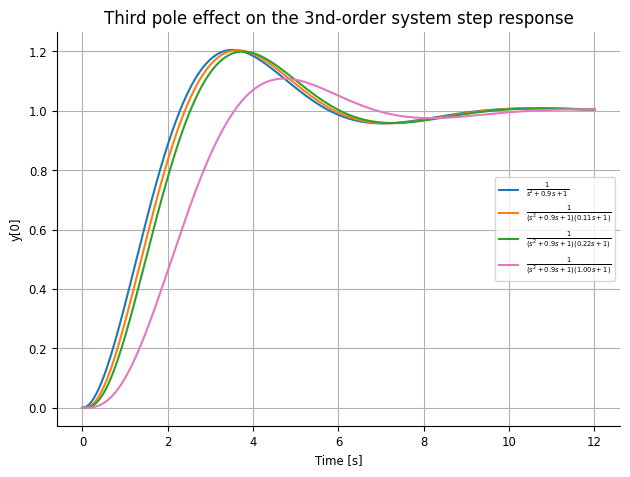

In [11]:
# run-python
s = ct.TransferFunction.s
tt = np.linspace(0.0,12.0,512)
sys1 = 1/(s**2 + 2*0.45*s +1)
resp2 = sys1.step_response(tt)
resp2.plot(label=r'$\frac{1}{s²+0.9s+1}$',title='')
ax = plt.gca()
fig = plt.gcf()
for γ in [1/9,1/4.5,1.0]:#0.25, 0.5, 0.75, 1.0]:
	sys2 = 1 / (γ * s + 1)
	sys = ct.series(sys1,sys2)
	resp1 = sys.step_response(tt)
	formula =f"$\\frac{{1}}{{(s^2+0.9s+1)({γ:.2f} s+1)}}$" 
	resp1.plot(ax=ax,label=formula)
ax.grid()
ax.set_title('Third pole effect on the 3nd-order system step response')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

The response of a third-order system can be approximated by the dominant roots of the second-order system as long as the real part of the dominant roots is less than one tenth of the real part of the third root (${1\over\gamma}\ge10\zeta\omega_{n}$)

+ **Effect of the zero:**

Consider now the following  2nd-order transfer function with finite zero:

$$
H_{cl}(s)={{\omega_{n}²\over a}(s+a)\over s²+2\zeta\omega_{n}s+\omega_{n}²}
$$
And let's examine the effect of this zero as it's moves forward with the following values: $\frac{a}{\zeta\omega_{n}}=0.5,1.0,2.0,10.0$ 

,a,RiseTime,SettlingTime,Overshoot,PeakTime,SteadyStateValue
0,None,2.093259,5.980741,4.598386,4.385876,1.0
1,0.35,0.299037,7.276568,76.125779,1.594864,1.0
2,0.7,0.897111,4.884271,21.877583,2.192938,1.0
3,1.4,1.594864,5.282987,7.163221,3.289407,1.0
4,7.0,2.093259,5.881061,4.648095,4.286197,1.0


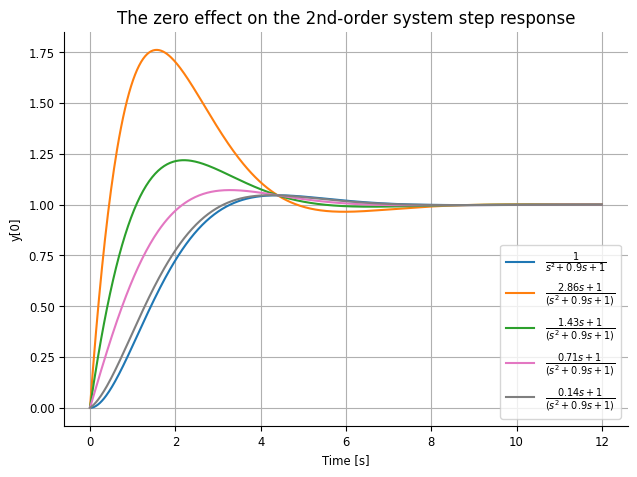

In [12]:
# run-python
import pandas as DF
zeta, wn = 0.7, 1.0
tt = np.linspace(0.0,12.0,512)
sys1 = wn**2 / ct.parallel(s**2,2*wn*zeta*s,wn**2)
resp2 = sys1.step_response(tt).plot(label=r'$\frac{1}{s²+0.9s+1}$',title='')
fig = plt.gcf()
ax = plt.gca()
step_info = ct.step_info(sys1)
performances_keys = ['RiseTime','SettlingTime','Overshoot','PeakTime','SteadyStateValue']
df_col_names = [*filter(lambda key: key in performances_keys,step_info.keys())]
df_col_names.insert(0,'a')
df = DF.DataFrame(columns=df_col_names)
for key in df.columns:
    if key == 'a': 
        df.loc[0,key] = None
    else:
        df.loc[0,key] = step_info[key]
    
for (i,a) in enumerate(np.array([0.5,1.0,2.0,10])*zeta*wn):
    sys2 = (s+a)/a
    sys = ct.series(sys1,sys2)
    step_info = ct.step_info(sys)
    for key in df.columns.tolist():
        if key == 'a': 
            df.loc[i+1,key] = a
        else:
            df.loc[i+1,key] = step_info[key]
    formula =f"$\\frac{{{1/a:.2f}s+1}}{{(s^2+0.9s+1)}}$" 
    sys.step_response(tt).plot(ax=ax,label=formula)

# plt.axhline(y=0.98,color='k', ls='--',label=r'$1-\delta$')
# plt.axhline(y=1.02,color='k', ls='--',label=r'$1+\delta$')
ax.grid()
ax.set_title('The zero effect on the 2nd-order system step response')
ax.legend(loc='lower right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
df

As the ratio $a/ζω_{n}$ ­increases, the finite zero moves farther into the left half-plane and away from the poles, and the step response approaches the second-order system response, as expected.
The correlation of the time-domain response of a system with the s-plane ­location of the poles of the closed-loop transfer function is a key concept in understanding system performance in the closed-loop.

***Exercise: Parameters selection***
A single-loop feedback control system is shown in the figure below: 

![](pics/diag55.svg)

We need to select the controller gain K and the parameter p so that the time-domain specifications are satisfied. The transient response to a unit step is specified to have a percent overshoot of $PO ≤ 5\%$ and a settling time to within $2\%$ of the final value of
$t_s ≤ 4 s$. Find the parameters $K$ and $p$ that satisfy these requirements.

+ **Combined impact of zero and third pole on 2nd-order closed-loop system unit step response**
  The transfer function is given now by the following expression:
$$
H_{cl}={{\omega_{n}²\over a}(s+a)\over (s²+2\zeta\omega_{n}s+\omega_{n}²)(\tau s+1)}
$$
  Let's take $\zeta\omega_{n}=3,\, \tau=0.16 \text{ and }a=2.5$

***Poles and zeros location:***


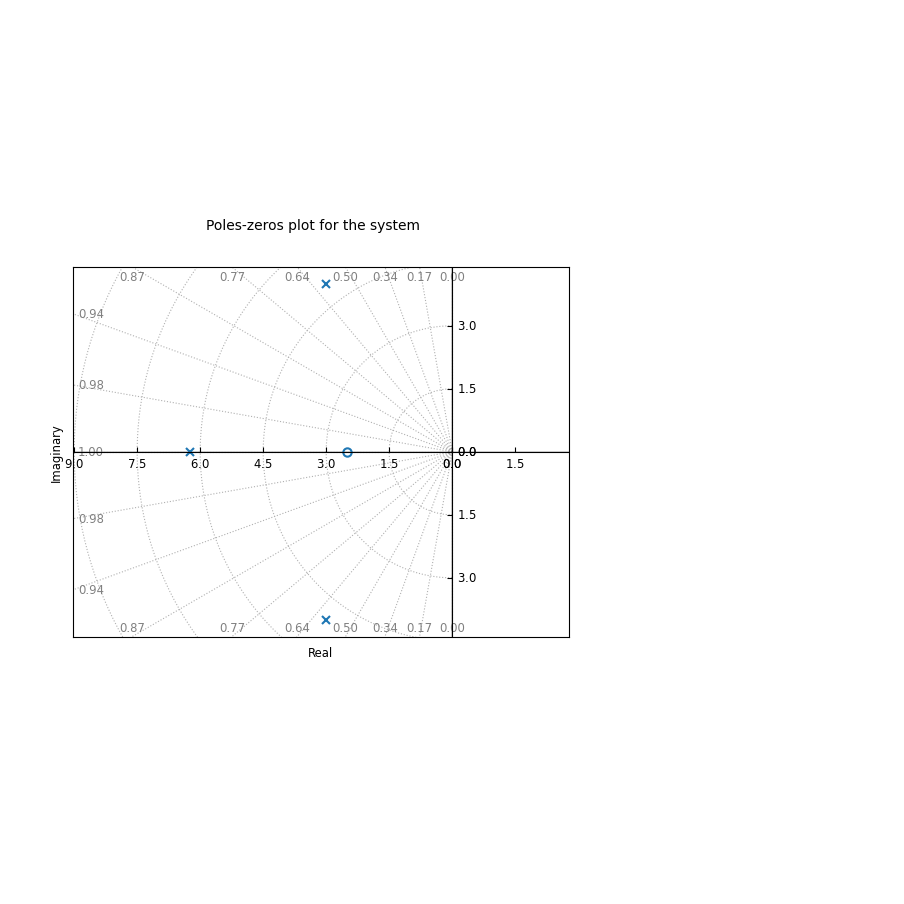

In [13]:
# run-python
wn, zeta, tau, a = (5,0.6,0.16,2.5)
s = ct.TransferFunction.s
sys1, sys2,sys3 = [wn**2*(s+a)/a,1/(tau*s+1),1/(s**2+2*wn*zeta*s+wn**2)]
sys = ct.series(sys1,sys2,sys3)
# fig = plt.figure()
# ax = fig.add_subplot(111,polar=True)
pzmap = ct.pole_zero_map(sys)
pzmap.plot(title='Poles-zeros plot for the system',grid=True)

***Step response:***

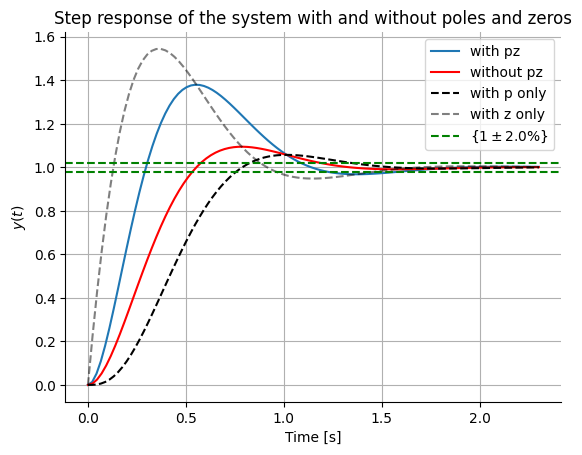

In [14]:
# run-python
wn, zeta, tau, a, delta = (5,0.6,0.16,2.5,0.02)
num1,den1, num2,den2, num3,den3 = ([wn**2],[1,2*wn*zeta,wn**2],[1],[tau,1],[1/a,1],[1])
sys1, sys2,sys3 = [ct.tf(num1,den1),ct.tf(num2,den2),ct.tf(num3,den3)]
sys = ct.series(sys1,sys2,sys3)
fig = plt.figure()
ax = fig.add_subplot(111)
sys.step_response().plot(ax=ax,label='with pz')
sys_stepInfo = ct.step_info(sys)
sys1_stepInfo = ct.step_info(sys1)
# for key in sys_stepInfo.keys():
	# match key:
		# case 'RiseTime':
		#	print(f'RiseTime: {sys_stepInfo['RiseTime']:.4f}s vs {sys1_stepInfo['RiseTime']:.4f}s')
		# case 'SettlingTime':
		#	print(f'SettlingTime: {sys_stepInfo['SettlingTime']:.4f} s vs {sys1_stepInfo['SettlingTime']:.4f}s')
		# case 'Overshoot': 
		# 	print(f'Overshoot: {sys_stepInfo['Overshoot']:.2f} % vs {sys1_stepInfo['Overshoot']:.2f} %')
		# case 'PeakTime': 
		#	print(f'Peak time: {sys_stepInfo['PeakTime']:.4f} s vs {sys1_stepInfo['PeakTime']:.4f}s')
sys1.step_response().plot(ax=ax,color='r',label= 'without pz')
ct.series(sys1,sys2).step_response().plot(ax=ax,linestyle='--',color='k',label= 'with p only')
ct.series(sys1,sys3).step_response().plot(ax=ax,linestyle='--',color='k',label= 'with z only',alpha=0.5)
ax.grid(True)
ax.set_title('Step response of the system with and without poles and zeros')
ax.set_ylabel(r'$y(t)$')
ax.axhline(y=0.98,color='g', ls='--',label=f'{{$1\\pm {delta*100}\\%$}}')
ax.axhline(y=1.02,color='g', ls='--')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 5. s-Plane root location and transient response
The transient response of a closed-loop feedback system can be describe in terms of location of the poles: 
$$
Y(s) ={1\over s}+\sum\limits_{i=1}^{M}{A_{i}\over s+\sigma_{i}}+\sum\limits_{k=1}^N{B_{k}s+C_{k}\over s² + 2\alpha_{k}s + (\alpha_{k}² +\omega_{k}²)}
$$
Where $A_{i}, B_{k}, C_{k}:$ are constants and $\sigma_{i},-\alpha_k\mp\jmath\omega_{k}$  are the poles of the system.  

By taking the inverse Laplace transform of the previous expression we find out the expression of $y(t)$
$$
y(t) = u(t) + \sum\limits_{i=1}^{M}A_{i}e^{-\sigma_{i}t}u(t) + \sum\limits_{k=1}^{N}D_{k}e^{-\alpha_{k}t}\sin(\omega_{k}t + \theta_{k})
$$
Where $D_{k}, \theta_{k}$ are constants that depends on $B_{k}, C_{k}, \alpha_{k} \text{ and  } \omega_{k}$. The transient response is composed of three terms. The steady-state terms, exponential decaying terms and sinusoidal damping terms. As we have noticed earlier, for the output to be stable, the real parts of the inputs must be localized in the left-hand portion of the s-plane.

The control system designer must anticipate how adding, removing, or relocating the poles and zeros of  $H_{cl}(s)$ in the complex plane will affect the step and impulse responses. Additionally, they should be able to visualize the necessary adjustments to the poles and zeros of $H_{cl}(s)$ to achieve the desired changes in these responses.

An experienced designer knows that the placement of zeros affects a system's response. The poles of $H_{cl}(s)$ dictate response modes, while the zeros determine the weight of each mode function. For example, moving a zero closer to a pole reduces its contribution to the output. This directly impacts $A_{i}$  and $D_{k}$; a zero near the pole at $s = -\sigma_i$ results in a smaller $A_i$.

# 6. Steady-state error and feedback system
One of the fundamental reasons for using feedback, despite its cost and increased
complexity, is the attendant improvement in the reduction of the steady-state error of the system. The steady-state error of a stable closed-loop system is usually ­several orders of magnitude smaller than the error of an open-loop system. 

Consider a unity negative feedback system. In the absence of external disturbances, and measurement noise $(N(s)=T_{d}(s)=0)$, the tracking error is:
$$
E(s) = {1\over 1+L(s)}R(S)
$$
Using the final value theorem for computing the steady-state tracking error $e_{ss}$ yields:
$$
\lim_{t\rightarrow\infty}e(t) = e_{ss}=\lim_{s\rightarrow0}s E(s)=\lim_{s\rightarrow0}{s R(s)\over 1+L(s)}
$$
+ **Step input:** The steady-state error for the step input is given by:
$$
e_{ss}={R_{0}\over 1+L(0)}
$$
With $R(s)=\frac{R_{0}}{s}$. The steady-state error is completely determined by the loop transfer function $L(s)$ considered at DC frequency $(s=0)$. Let denote $L(0)$ by $K_{p}$ the *position error constant* then the steady-state tracking error is given by:

$$
e_{ss}={R_{0}\over 1 + K_{p}}
$$

+ **Ramp input:** The steady-state error for the ramp input (velocity) with a slope $R_{0}$ is:
$$
e_{ss}=\lim_{s\rightarrow0}s E(s)=\lim_{s\rightarrow0}{R_{0}\over s+s L(s)}
$$
we can express $L(s)$ as:
$$
L(s) = C(s)P(S) = {K \prod\limits_{i}(s-z_{i})\over s^{N}\prod\limits_{k}(s-p_{k})}
$$
if $N=0$ then $e_{ss}\rightarrow \infty$ but if $N=1$ then: 
$$
e_{ss}={A\over K_{v}}
$$ where $K_{v}= {K\prod\limits_{i}z_{i}\over\prod\limits_{k}p_{k}}$ is the *velocity error constant*. The $e_{ss}\rightarrow0$ when $N\geq 2$

+ **Acceleration input:** When the system input is $r(t)=\frac{R_{0}t²}{2}$, the steady-state error is:
$$
e_{ss}=\lim\limits_{s\rightarrow0}{R_{0}\over s^{2}(1+L(s))}
$$
For $N<2$ the $e_{ss}\rightarrow\infty$. If $N=2$ then:
$$
e_{ss}=R_{0}/K_{a}
$$Where $K_{a}= {K\prod_{i}z_{i}\over\prod_{k}p_{k}}$ is the *acceleration error constant*. If $N>2\Rightarrow e_{ss}\rightarrow 0$.

>Control systems are often described in terms of their type number and the error constants, $K_p$ , $K_v$ , and $K_a$.

# 7. Performance indices
In modern control theory, we can define the required performance of a system quantitatively. This allows us to calculate or measure a performance index, which can then be used to assess the system's performance. These quantitative measures are extremely valuable for both the design and operation of control systems.

A system is considered an optimal control system when its parameters are adjusted to ensure that the performance index reaches an extremum, typically a minimum value. For a performance index to be useful, it must always be a positive number or zero. The best system is defined as the one that minimizes this index.

> **A performance index quantitatively measures system performance, emphasizing key specifications.** 

## 7.1. Integral of square of the error (ISE) as performance index
A common performance index is the ISE defined as:
$$
\mathrm{ISE}=\int_{0}^{T}e²(t)dt 
$$
The upper limit of this integral is a finite time selected by the control system designer. It is convenient to chose $T = t_s$ (settling time) 

***Example 1:***
Let's consider the following closed-loop second-order control system, which is represented by the transfer function:
$$
H_{cl}(s) = {1 \over s² +0.65s +1}
$$

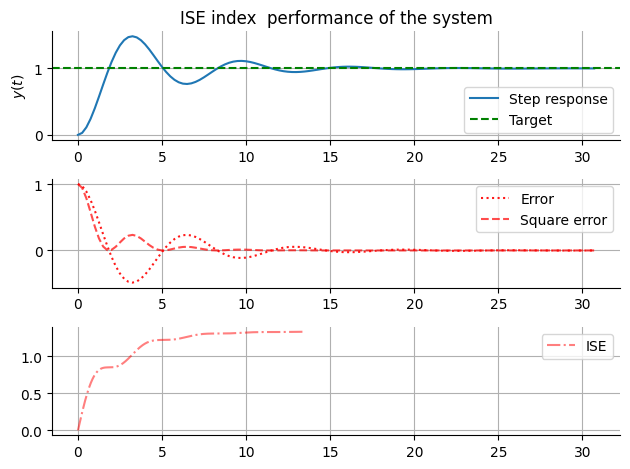

In [15]:
# run-python
import warnings  
warnings.filterwarnings("ignore")
from scipy.integrate import quad
from scipy.interpolate import CubicSpline
num, den = ([1],[1,.45,1])
sys = ct.tf(num,den)
ts = ct.step_info(sys,SettlingTimeThreshold=0.05)['SettlingTime']
tt, y = sys.step_response()
error = 1.0 - np.array(y)
sq_error = error**2
cs = CubicSpline(tt,error)
ise = [quad(lambda t: cs(t)**2, tt[0],tau)[0] for tau in np.linspace(0,ts,512)]
fig = plt.figure()
ax1 = fig.add_subplot(311)
ax1.plot(tt,y,label='Step response')
ax1.set_title('ISE index  performance of the system')
ax1.set_ylabel(r'$y(t)$')
ax1.axhline(y=1.0,color='g', ls='--', label='Target')
ax1.grid()
ax1.legend()
ax2 = fig.add_subplot(312, sharex=ax1)
ax2.plot(tt,cs(tt), label='Error',ls='dotted',color='red',alpha=0.9)
ax2.plot(tt,cs(tt)**2, label='Square error',ls='dashed',color='red', alpha=0.7)
ax2.grid()
ax2.legend()
ax3 = fig.add_subplot(313,sharex=ax1)
ax3.plot(np.linspace(0,ts,512),ise, label='ISE',ls='dashdot',color='red',alpha=0.5)
ax3.grid()
ax3.legend()
fig.tight_layout()
for ax in [ax1,ax2,ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

This criterion distinguishes between excessively over-damped and excessively under-damped systems. The minimum value of the integral occurs at a compromise value of the damping. The Integral of Squared Error (ISE) is mathematically convenient for both analytical and computational purposes. 
There exist other performance index such:
$$
\begin{aligned}
\mathrm{IAE} &= \int_{0}^{T}\vert e(t)\vert dt,\\[0.25cm]
\mathrm{ITAE} &= \int_{0}^{T}t\vert e(t)\vert dt,\\[0.25cm]
\mathrm{ITSE} &= \int_{0}^{T}t\vert e²(t)\vert dt,\\[0.25cm]
\end{aligned}
$$

the general form of the performance index is given by:
$$
\mathrm{I}=\int_{0}^{T}f(e(t), r(t), y(t),t)dt
$$ 
where $f$ is a function of the error, input, output and time.

***Example 2:***
Consider a telescope pointing control system shown in the figure below:
![](pics/diag56.svg)

Assuming a zero reference signal $(R(s)=0)$, we can establish the follow relation between the output and the disturbance signal: 
$$
{Y(s)\over T_{d}(s)} = {s² + K_{1}K_{3}s\over s²+K_{1}K_{3}s+K_{1}K_{2}K_{p}}
$$

Typical value for the constant $K_{1}=0.5$ and $K_{1}K_{2}K_{p}=2.5$. In this case the goal is to minimize $y(t)$. For a unit step disturbance, the minimum ISE can be evaluated analytically. The attitude is given by:
$$
y(t)=\frac{\sqrt{10}}{\beta}e^{-0.25K_{3}t}\sin\left(\frac{\beta}{2}t+\psi\right)
$$ 
where $\beta=\sqrt{0.25K_{3}² -10}$ . Squaring $y(t)$ and integrating the results yields:
$$
\mathrm{ISE}=\int_{0}^{\infty}\frac{10}{\beta²}e^{-0.5K_{3}t}\left(\frac{1}{2} - \frac{1}{2}\sin(\beta+2\psi)\right)dt=\frac{1}{K_{3}}+0.1K_{3}
$$

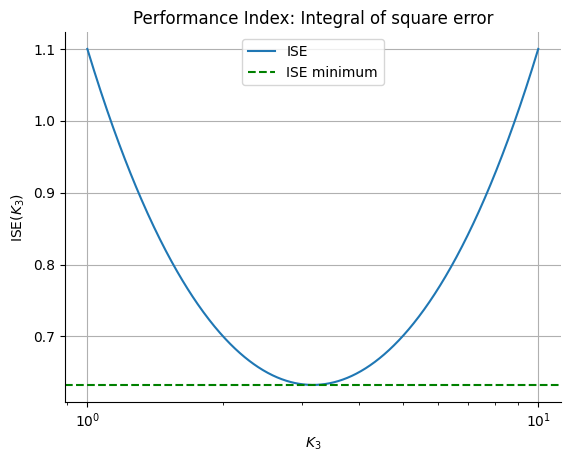

In [16]:
# run-python
K3 = np.linspace(1,10,1024)
ise = 1/K3 + 0.1*K3
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(K3,ise,label='ISE')
ax.axhline(y=1/np.sqrt(10)+0.1*np.sqrt(10),color='g', ls='--', label='ISE minimum')
ax.set_xscale('log')
ax.set_xlabel(r'$K_3$')
ax.set_ylabel(r'$\mathrm{ISE}(K_3)$')
ax.set_title('Performance Index: Integral of square error')
ax.grid()
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

The optimum system response according to the value of $K_{3}$ that minimize the ISE is given below:

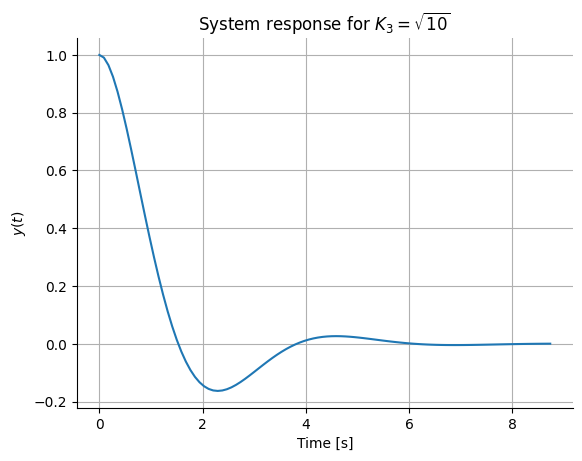

In [17]:
# run-python
K1,K3,K1K2Kp=0.5,np.sqrt(10),2.5
num, den = [1,K1*K3,0], [1, K1*K3,K1K2Kp]
sys = ct.tf(num,den)
fig = plt.figure()
ax = fig.add_subplot(111)
sys.step_response().plot(ax=ax)
ax.set_title(r'System response for $K_3=\sqrt{10}$')
ax.set_ylabel(r'$y(t)$')
ax.grid()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 8. Simplification of linear system
It is quite useful to study complex systems with high-order transfer functions by employing lower-order approximation models. Several methods are available for reducing the order of a system's transfer function. One relatively simple approach is to eliminate a certain insignificant pole, specifically a pole with a higher negative real part. This pole has a minimal effect on the system transient response.

***Example 1:***
Consider a third-order system with the following transfer function:
$$
H_{cl}(s)=\frac{K}{s(s+2)(s+30)}
$$
We can safely neglect the pole $p_{3}=-30$ and approximate the transfer function of this system by a 2nd-order transfer function:
$$
H_{cl,r}(s)=\frac{K}{30}\frac{1}{s(s+2)}
$$

In [18]:
# run-python
K = 1
zs,ps1,ps2,Ks1 = [],[0,-2,-30],[0,-2],K
Ks2 = K/-ps1[-1]
H1 = ct.zpk(zs,ps1,Ks1)
H2 = ct.zpk(zs,ps2,Ks2)
H1

TransferFunction(
array([1.]),
array([ 1, 32, 60,  0]),
outputs=1, inputs=1)

In [19]:
H2

TransferFunction(
array([0.03333333]),
array([1, 2, 0]),
outputs=1, inputs=1)

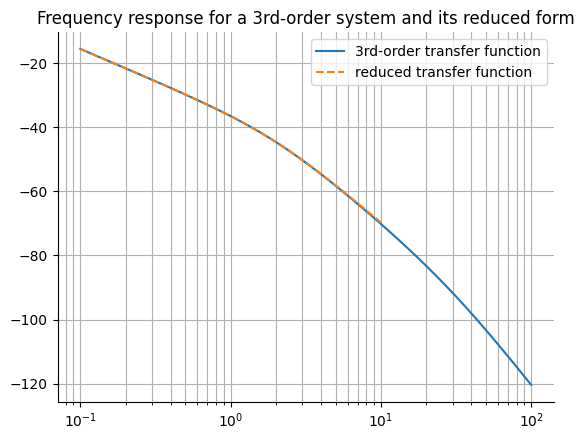

In [20]:
Y1,_,w1 = H1.frequency_response() 
Y2,_,w2 = H2.frequency_response()
fig = plt.figure()
ax = fig.add_subplot(111)
ax.semilogx(w1,20*np.log10(Y1),label='3rd-order transfer function') 
ax.semilogx(w2,20*np.log10(Y2),label='reduced transfer function',ls='dashed')
ax.grid(which='both')
ax.legend()
ax.set_xscale('log')
ax.set_title('Frequency response for a 3rd-order system and its reduced form')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

Consider the high-order system be described by the transfer function:
$$
H_{cl}(s)=K\frac{b_{m}s^{m}+b_{m-1}s^{m-1}+\cdots+b_{1}s+1}{a_{n}s^{n}+a_{n-1}s^{n-1}+\cdots+a_{1}s+1}
$$
in which the poles are in left-hand s-plane and $m\leq n$. The lower-order approximate transfer function is:
$$
H_{cl,r}(s)=K\frac{c_{p}s^{p}+\cdots+c_{1}s+1}{d_qs^q+\cdots+d_{1}s+1}
$$

where $p\leq q<n$. We aim to match $H_{cl}(s)$ and $H_{cl,r}(s)$ over a large interval of frequencies which is equivalent to:
$$
\frac{H_{cl}(\jmath\omega)}{H_{cl,r}(\jmath\omega)}\approx 1
$$ 
for various $\omega$.
Let's define the following expression from the numerator $N(s)$ and denominator polynomial $D(s)$ of the previous ratio:
$$
N_{2t}(s)=\sum\limits_{k=0}^{2t}\frac{(-1)^{t+k}N^{(k)}(0)N^{(2t-k)}(0)}{k!(2t-k)!}\quad t=0,1,2\dots
$$ 
we use the same definition for the $D_{2t}(s)$. To find the $c_{i}$ and $d_{i}$ coefficients we solve the following equality:
$$
N_{2t}(s)=D_{2t}(s)\quad \text{ for } t=1,2,\dots
$$
up to the number required to solve unknown coefficients.

***Exercise***
Simplify the model described by this 3rd_order transfer function:
$$
H_{cl(s)}= {6\over s³+6s²+11s+6}
$$

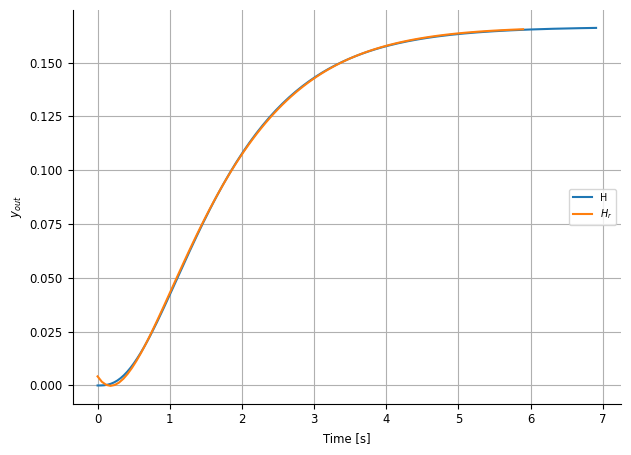

In [21]:
# run-python
s = ct.TransferFunction.s
H = 1 / (s**3 + 6*s**2 + 11*s + 6)
Hr = (0.004223 * s**2 - 0.04253*s + 0.2368)/(s**2 + 2.343*s + 1.421)
H.step_response().plot(title='',label='H')
ax = plt.gca()
Hr.step_response().plot(ax=ax,label=r'$H_r$')
ax.grid()
ax.set_title('')
ax.set_ylabel(r'$y_{out}$')
[ax.spines[pos].set_visible(False) for pos in ['top', 'right']];

# 9. Design example (attitude control of an airplane)
Every time we fly on a commercial airliner, we benefit from automatic control systems that enhance aircraft handling and assist pilots, especially during long flights. The relationship between flight and controls began with the Wright brothers, who used wind tunnels and systematic design approaches to achieve powered flight, contributing significantly to their success.

The Wright brothers emphasized pilot-controlled flight, inspired by how birds twist their wings to manage rolling motion. They designed their aircraft with mechanical systems for wing warping, which is now obsolete; modern aircraft use ailerons for roll control, as shown in figure below:  
![](pics/diag57.svg)
Additionally, they used front-mounted elevators for pitch control and rudders for yaw. Today, elevators are commonly found at the tail of the aircraft, but rudders are still used for lateral control.

The first controlled, powered, unassisted takeoff flight took place in 1903 with the Wright Flyer I, also known as Kitty Hawk. The first practical airplane, the Flyer III, was capable of flying figure eights and could remain airborne for up to half an hour. A significant but often overlooked contribution of the Wright brothers was their development of three-axis flight control. The ongoing desire to fly faster, lighter, and longer has driven further advancements in automatic flight control.
The main topic of this section is control of the automatic rolling motion of an airplane. The elements of the design process emphasized in this chapter are illustrated in the figure below:

![](pics/diag58.svg)